# Week 1 — 05: Weekly Contrarian Trading Strategy

This notebook implements a simple weekly contrarian strategy inspired by the provided video. The rule applied across the entire available EGX universe is:

- Buy 5 EGP of a stock when its return over the previous trading week (5 trading days) is ≤ -5% (a loss of at least 5%).
- Sell 10 EGP of a stock when its return over the previous trading week (5 trading days) is ≥ +10% (a gain of at least 10%).

This is a contrarian (mean-reversion style) rule because it buys recent losers and reduces exposure to recent winners. Fractional shares are allowed to reproduce the video logic (
5
). This is an educational historical simulation — it omits commissions, slippage, taxes, and liquidity constraints.

## Project setup

We reuse the same project-root setup pattern used in the course notebooks and the `DataFeed` loader. No external packages beyond NumPy and Matplotlib (already used in the project) are imported.

In [13]:
import sys, os
# Walk up until we find the repository root that contains `src`
while (not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd()):
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed

# Load the full EGX universe bundled with the project
feed = DataFeed.from_dir('data/egx')

## Parameters

Configure the strategy parameters here.

- `buy_threshold = -0.05` means a loss of 5%.
- `sell_threshold = 0.10` means a gain of 10%.
- `buy_notional = 5.0` means buy 5 EGP worth.
- `sell_notional = 10.0` means sell 10 EGP worth.
- `lookback_days = 5` approximates one trading week as five trading days.

In [14]:
# Strategy parameters
initial_cash = 1000.0
lookback_days = 5
buy_threshold = -0.05
sell_threshold = 0.10
buy_notional = 5.0
sell_notional = 10.0

## Inspect the data

Print basic dataset information and create convenient local variables for `dates`, `symbols`, and `close`. The repository `DataFeed` exposes these attributes: `close`, `returns`, `volume`, `dates`, `symbols`, and `n_days`.

In [15]:
dates = feed.dates
symbols = feed.symbols
close = feed.close  # shape: (days, symbols)
n_days = feed.n_days
n_stocks = feed.n_assets

print('number of stocks:', n_stocks)
print('number of historical days:', n_days)
print('first date:', dates[0])
print('final date:', dates[-1])
print('close.shape:', close.shape)
print('first few symbols:', symbols[:10])

number of stocks: 34
number of historical days: 1159
first date: 2021-10-20 00:00:00
final date: 2026-07-30 00:00:00
close.shape: (1159, 34)
first few symbols: ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY']


## Validate the data and parameters

Simple checks ensure nothing obviously mismatches the strategy assumptions.

In [16]:
# Basic validations
assert close.ndim == 2, 'close must be two-dimensional (days, stocks)'
assert close.shape[0] == n_days
assert close.shape[1] == n_stocks
assert n_days > lookback_days, 'not enough history for the chosen lookback'
assert initial_cash > 0
assert buy_notional > 0
assert sell_notional > 0
assert buy_threshold < 0, 'buy threshold should be negative (loss)'
assert sell_threshold > 0, 'sell threshold should be positive (gain)'

print('data and parameters validated')

data and parameters validated


## Calculate weekly returns (signal formation)

We compute a `signal_return` for each execution date `t` using only information available up to `t - 1` (no look-ahead). The signal is the percentage change over the previous `lookback_days` ending at `t - 1`:

signal_return[t, j] = close[t-1, j] / close[t-1-lookback_days, j] - 1

We initialize unavailable observations with `np.nan`.

In [17]:
weekly_signals = np.full_like(close, fill_value=np.nan, dtype=float)

for t in range(n_days):
    # signal for day t uses data up to t-1 -> requires t-1 and t-1-lookback_days
    idx_recent = t - 1
    idx_earlier = t - 1 - lookback_days
    if idx_recent < 0 or idx_earlier < 0:
        continue
    recent = close[idx_recent]
    earlier = close[idx_earlier]
    # compute per-stock safely
    for j in range(n_stocks):
        p_recent = recent[j]
        p_earlier = earlier[j]
        if (not np.isfinite(p_recent)) or (not np.isfinite(p_earlier)):
            weekly_signals[t, j] = np.nan
            continue
        if p_recent <= 0 or p_earlier <= 0:
            weekly_signals[t, j] = np.nan
            continue
        weekly_signals[t, j] = p_recent / p_earlier - 1.0

print('Weekly signals computed (aligned to execution dates)')

Weekly signals computed (aligned to execution dates)


## Initialize portfolio state and histories

We use fractional shares to implement 
5
. Holdings represent fractional shares per symbol.

In [18]:
cash = float(initial_cash)
holdings = np.zeros(n_stocks, dtype=float)  # fractional shares allowed
latest_valid_price = np.full(n_stocks, np.nan, dtype=float)

portfolio_values = np.full(n_days, np.nan, dtype=float)
cash_history = np.full(n_days, np.nan, dtype=float)
invested_history = np.full(n_days, np.nan, dtype=float)
n_positions_history = np.full(n_days, 0, dtype=int)
daily_buy_ops = np.zeros(n_days, dtype=int)
daily_sell_ops = np.zeros(n_days, dtype=int)

total_buy_operations = 0
total_sell_operations = 0
skipped_buy_operations = 0

trade_log = []

eps = 1e-12

## Walk-forward backtest

We iterate through each date chronologically. For execution on day `t` we use the signal computed at `t` (which itself used only data up to `t - 1`). Sells are executed before buys.

In [19]:
for t in range(n_days):
    today_price = close[t]  # execution price for day t
    signal = weekly_signals[t]  # may contain NaNs

    # Update latest valid prices (used for valuation when today's price missing)
    for j in range(n_stocks):
        p = today_price[j]
        if np.isfinite(p) and p > 0:
            latest_valid_price[j] = p

    # SELL step: execute sells first in the order of symbols
    sells_today = 0
    for j in range(n_stocks):
        sig = signal[j]
        p = today_price[j]
        if not (np.isfinite(sig) and np.isfinite(p) and p > 0):
            continue
        if sig >= sell_threshold and holdings[j] > 0:
            position_value = holdings[j] * p
            actual_sell_value = min(sell_notional, position_value)
            if actual_sell_value <= eps:
                continue
            shares_to_sell = actual_sell_value / p
            # Prevent tiny floating negatives
            shares_to_sell = min(shares_to_sell, holdings[j])
            holdings[j] -= shares_to_sell
            cash += actual_sell_value
            sells_today += 1
            total_sell_operations += 1
            trade_log.append({
                'date': str(dates[t]),
                'symbol': symbols[j],
                'operation': 'SELL',
                'signal_return': float(sig),
                'price': float(p),
                'notional': float(actual_sell_value),
                'shares': float(shares_to_sell),
                'cash_after': float(cash),
                'position_shares_after': float(holdings[j])
            })

    daily_sell_ops[t] = sells_today

    # BUY step: deterministic order = feed.symbols order
    buys_today = 0
    for j in range(n_stocks):
        sig = signal[j]
        p = today_price[j]
        if not (np.isfinite(sig) and np.isfinite(p) and p > 0):
            continue
        if sig <= buy_threshold:
            actual_buy_value = min(buy_notional, cash)
            if actual_buy_value <= eps:
                skipped_buy_operations += 1
                continue
            shares_to_buy = actual_buy_value / p
            holdings[j] += shares_to_buy
            cash -= actual_buy_value
            buys_today += 1
            total_buy_operations += 1
            trade_log.append({
                'date': str(dates[t]),
                'symbol': symbols[j],
                'operation': 'BUY',
                'signal_return': float(sig),
                'price': float(p),
                'notional': float(actual_buy_value),
                'shares': float(shares_to_buy),
                'cash_after': float(cash),
                'position_shares_after': float(holdings[j])
            })

    daily_buy_ops[t] = buys_today

    # End-of-day valuation: cash + invested (use latest_valid_price for positions)
    invested = 0.0
    n_positions = 0
    for j in range(n_stocks):
        if holdings[j] > 0:
            p_val = latest_valid_price[j]
            if np.isfinite(p_val) and p_val > 0:
                invested += holdings[j] * p_val
                n_positions += 1
    portfolio_value = cash + invested
    # Ensure non-negative and finite
    if not np.isfinite(portfolio_value) or portfolio_value < 0:
        portfolio_value = float(cash) + float(max(0.0, invested))

    portfolio_values[t] = portfolio_value
    cash_history[t] = cash
    invested_history[t] = invested
    n_positions_history[t] = n_positions

# Done loop
print('Backtest completed')

Backtest completed


## Performance metrics

Compute final statistics including maximum drawdown. Maximum drawdown is computed from a running peak of the portfolio value.

In [20]:
valid_idx = np.isfinite(portfolio_values)
if not np.any(valid_idx):
    raise RuntimeError('No valid portfolio values computed')

initial_capital = initial_cash
final_portfolio_value = float(portfolio_values[valid_idx][-1])
profit_loss = final_portfolio_value - initial_capital
total_return_pct = profit_loss / initial_capital * 100.0

# Maximum drawdown (EGP & %)
running_peak = np.maximum.accumulate(np.where(valid_idx, portfolio_values, -np.inf))
# replace -inf running peaks before first valid with the first valid value to avoid div-by-zero
first_valid = np.argmax(valid_idx)
running_peak[:first_valid] = portfolio_values[first_valid]
drawdown_egp = running_peak - np.where(valid_idx, portfolio_values, running_peak)
with np.errstate(divide='ignore', invalid='ignore'):
    drawdown_pct = np.where(running_peak > 0, drawdown_egp / running_peak * 100.0, 0.0)
max_drawdown_egp = float(np.nanmax(drawdown_egp))
max_drawdown_pct = float(np.nanmax(drawdown_pct))

total_ops = total_buy_operations + total_sell_operations
unique_traded = len(set([t['symbol'] for t in trade_log]))
avg_positions_held = float(np.nanmean(n_positions_history))

print(f'Initial cash: {initial_capital:.2f} EGP')
print(f'Final portfolio value: {final_portfolio_value:.2f} EGP')
print(f'Profit / loss: {profit_loss:.2f} EGP')
print(f'Total return: {total_return_pct:.2f}%')
print(f'Max drawdown: {max_drawdown_egp:.2f} EGP ({max_drawdown_pct:.2f}%)')
print(f'Total buy operations: {total_buy_operations}')
print(f'Total sell operations: {total_sell_operations}')
print(f'Total operations: {total_ops}')
print(f'Buy signals skipped due to insufficient cash: {skipped_buy_operations}')
print(f'Final cash: {cash:.2f} EGP')
print(f'Final invested value: {invested_history[~np.isnan(invested_history)][-1]:.2f} EGP')
print(f'Open positions: {int((holdings > 0).sum())}')
print(f'Unique stocks traded: {unique_traded}')
print(f'Average positions held through time: {avg_positions_held:.2f}')

Initial cash: 1000.00 EGP
Final portfolio value: 4233.30 EGP
Profit / loss: 3233.30 EGP
Total return: 323.33%
Max drawdown: 507.20 EGP (26.20%)
Total buy operations: 3847
Total sell operations: 1946
Total operations: 5793
Buy signals skipped due to insufficient cash: 1023
Final cash: 204.72 EGP
Final invested value: 4028.58 EGP
Open positions: 32
Unique stocks traded: 33
Average positions held through time: 28.99


## Final holdings summary

List symbols with positive remaining holdings, their fractional shares, latest price, and position value.

In [21]:
print('\nFinal holdings:')
open_positions = []
for j in range(n_stocks):
    if holdings[j] > 0:
        latest_p = latest_valid_price[j]
        pos_val = holdings[j] * latest_p if np.isfinite(latest_p) else np.nan
        open_positions.append((symbols[j], float(holdings[j]), float(latest_p), float(pos_val)))

if not open_positions:
    print('No positions open at the end of the backtest.')
else:
    for sym, sh, p, val in open_positions:
        print(f'{sym:6s}  shares={sh:.6f}  price={p:.2f}  value={val:.2f}')
    print(f'Total open positions: {len(open_positions)}')


Final holdings:
ABUK    shares=2.846537  price=73.00  value=207.80
ADIB    shares=0.584229  price=52.85  value=30.88
ALCN    shares=3.141048  price=29.44  value=92.47
AMOC    shares=30.262290  price=8.91  value=269.64
ARCC    shares=0.648521  price=56.10  value=36.38
BTFH    shares=73.651303  price=3.06  value=225.37
CCAP    shares=22.107943  price=5.17  value=114.30
CIEB    shares=8.713472  price=23.77  value=207.12
COMI    shares=1.091221  price=141.00  value=153.86
DOMTY   shares=1.045111  price=26.55  value=27.75
EAST    shares=3.185302  price=36.40  value=115.94
EFID    shares=2.210669  price=27.24  value=60.22
EFIH    shares=4.820274  price=22.65  value=109.18
EGAL    shares=0.144587  price=296.19  value=42.83
EMFD    shares=31.585848  price=11.25  value=355.34
ETEL    shares=3.043042  price=103.60  value=315.26
FWRY    shares=9.901212  price=18.77  value=185.85
GBCO    shares=3.266315  price=29.66  value=96.88
HRHO    shares=6.914487  price=26.20  value=181.16
ISPH    shares=4.

## Visualizations

Top: portfolio value, cash, invested value, and initial capital.
Bottom: daily buy and sell operations.

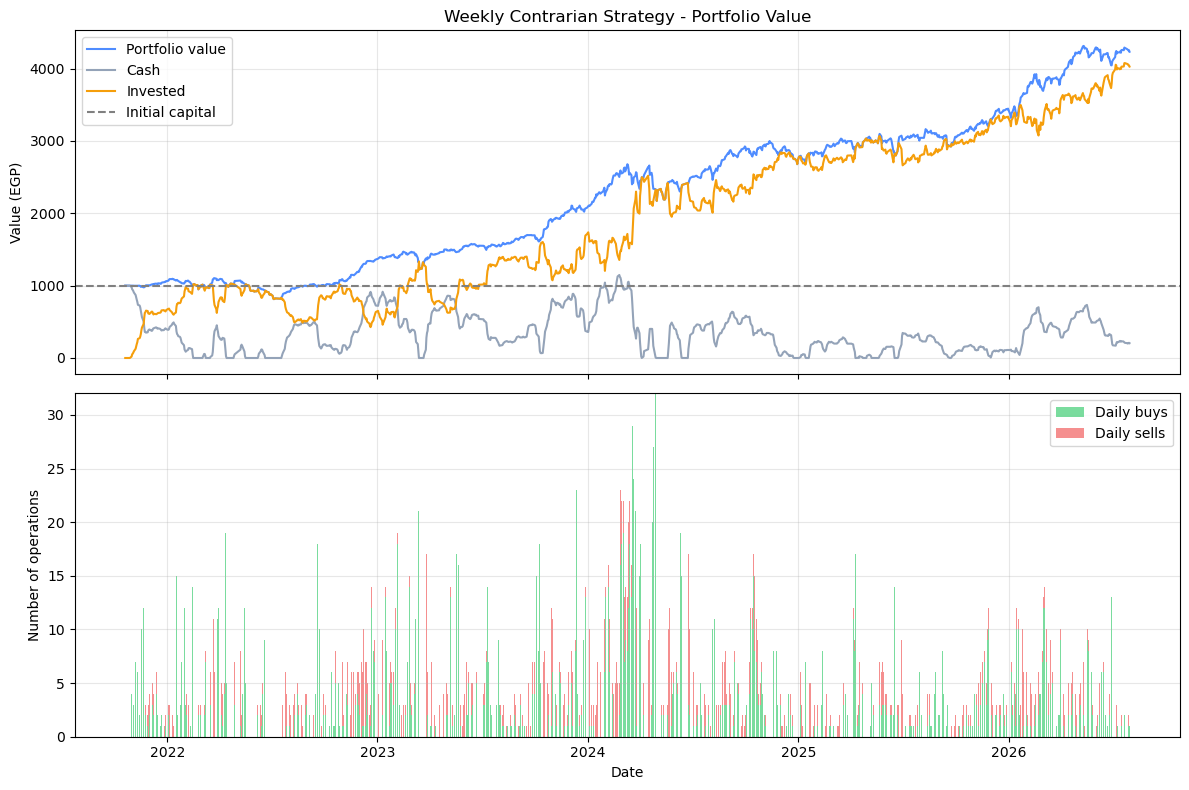

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(dates, portfolio_values, label='Portfolio value', color='#4f8cff')
ax1.plot(dates, cash_history, label='Cash', color='#94a3b8')
ax1.plot(dates, invested_history, label='Invested', color='#f59e0b')
ax1.axhline(initial_capital, color='gray', linestyle='--', label='Initial capital')
ax1.set_ylabel('Value (EGP)')
ax1.set_title('Weekly Contrarian Strategy - Portfolio Value')
ax1.legend()
ax1.grid(alpha=0.3)

# Operations per day
ax2.bar(dates, daily_buy_ops, label='Daily buys', color='#22c55e', alpha=0.6)
ax2.bar(dates, daily_sell_ops, label='Daily sells', color='#ef4444', alpha=0.6, bottom=daily_buy_ops)
ax2.set_ylabel('Number of operations')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Single-stock diagnostic (optional)

Plot a single stock's price with markers where its weekly signal generated a buy or sell. This is explanatory only.

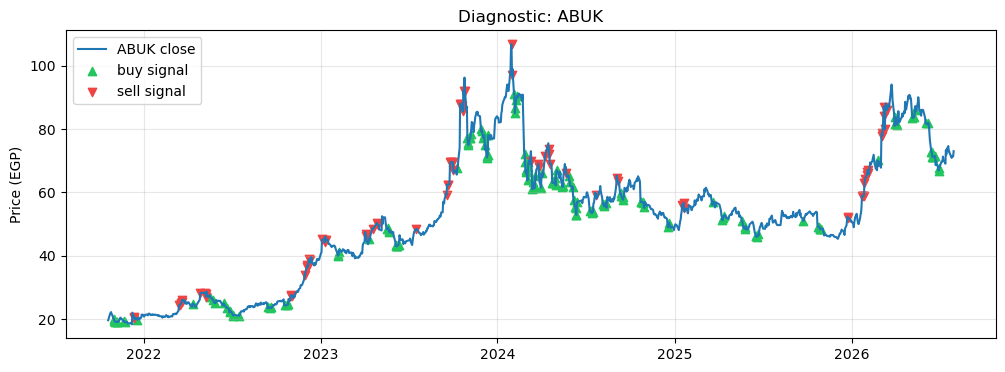

In [23]:
symbol_position = 0  # change to inspect another stock
sym = symbols[symbol_position]
prices = close[:, symbol_position]
signals = weekly_signals[:, symbol_position]
buy_idx = np.where(np.isfinite(signals) & (signals <= buy_threshold))[0]
sell_idx = np.where(np.isfinite(signals) & (signals >= sell_threshold))[0]

plt.figure(figsize=(12, 4))
plt.plot(dates, prices, label=f'{sym} close')
plt.scatter(dates[buy_idx], prices[buy_idx], marker='^', color='#22c55e', label='buy signal')
plt.scatter(dates[sell_idx], prices[sell_idx], marker='v', color='#ef4444', label='sell signal')
plt.title(f'Diagnostic: {sym}')
plt.ylabel('Price (EGP)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Explanation of results

- State whether the final portfolio value is above or below 1,000 EGP.
- Summarize how many operations occurred and whether cash constraints caused skips.
- Explain the maximum drawdown meaning and caution that this historical result is not proof of future profitability.
- Reiterate that fractional shares were used, there are no transaction costs, and the EGX daily dataset is an approximation.